# start

## importing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, fisher_exact, ttest_ind, mannwhitneyu, shapiro, kruskal, mannwhitneyu, pointbiserialr, norm

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

import itertools

sns.set_context("paper")
sns.set_style("whitegrid")

## custom functions

In [33]:
# Shapiro-Wilk

def normality_check(data, alpha=0.05):
    """
    Performs Shapiro-Wilk test and prints normality result along with summary stats.

    Parameters:
        data (array-like): Numeric dataset
        alpha (float): Significance threshold, default 0.05
    """
    stat, p = shapiro(data)
    print(f"Shapiro-Wilk statistic: {stat:.4f}, p-value: {p:.4f}")
    print("\nData Summary:")
    print(data.describe())

    if p > alpha:
        print("\n✅ Data looks normally distributed (parametric assumption OK)")
    else:
        print("\n⚠️ Data is not normally distributed (non-parametric)")

# Chi or Fisher

def compare_binary_by_group(df, feature, group_col="male"):
    """
    Compare a binary feature between two groups using Chi-squared or Fisher's exact test.

    Parameters:
    df : pandas.DataFrame
        DataFrame containing the data
    feature : str
        Name of the binary feature to compare
    group_col : str
        Name of the grouping column (default "male")
    """
    # Contingency table
    table = pd.crosstab(df[feature], df[group_col])
    print(f"Contingency table for {feature}:\n{table}\n")

    # Choose test depending on expected counts
    if (table.values < 5).any():
        stat, p = fisher_exact(table)
        print("Fisher's exact test p-value:", p)
    else:
        stat, p, dof, expected = chi2_contingency(table)
        print("Chi-squared test p-value:", p)

    # Column percentages
    col_pct = table.div(table.sum(axis=0), axis=1) * 100
    print("\nColumn percentages (% within feature):\n", col_pct.round(1))
    print("\n" + "-"*50 + "\n")

# t-test or Mann-Whitney U

def compare_continuous_by_group(df, feature, group_col="male", alpha=0.05):
    """
    Compare a continuous feature between two groups using t-test or Mann-Whitney U test.

    Parameters:
    df : pandas.DataFrame
        DataFrame containing the data
    feature : str
        Name of the continuous feature to compare
    group_col : str
        Name of the grouping column (default "male")
    alpha : float
        Significance level for Shapiro-Wilk normality test
    """
    # Split data by group
    group0 = df[df[group_col]==0][feature].dropna()
    group1 = df[df[group_col]==1][feature].dropna()

    # Test normality
    p0 = shapiro(group0).pvalue
    p1 = shapiro(group1).pvalue

    print(f"{feature}: Shapiro p-values -> group 0: {p0:.3f}, group 1: {p1:.3f}")

    # Decide test
    if p0 > alpha and p1 > alpha:
        # Both normal -> t-test
        stat, p = ttest_ind(group0, group1, equal_var=False)  # Welch's t-test
        test_name = "Student's t-test (Welch)"
        print(f"{test_name} p-value: {p:.4f}")
        print(f"Mean ± SD (group 0): {group0.mean():.2f} ± {group0.std():.2f}")
        print(f"Mean ± SD (group 1): {group1.mean():.2f} ± {group1.std():.2f}")
    else:
        # Non-parametric -> Mann-Whitney U
        stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
        test_name = "Mann-Whitney U test"
        print(f"{test_name} p-value: {p:.4f}")
        for g, name in zip([group0, group1], ["group 0", "group 1"]):
            median = g.median()
            q25 = g.quantile(0.25)
            q75 = g.quantile(0.75)
            min_val = g.min()
            max_val = g.max()
            print(f"{name}: median={median:.2f}, IQR=({q25:.2f}-{q75:.2f}), range=({min_val}-{max_val})")

    print("\n" + "-"*50 + "\n")

def slope_summary(result, base_var="yrs_from_baseline", inter_var=None):
    params = result.params
    cov = result.cov_params()
    inter_var = f"{base_var}:{inter_var}" if inter_var else None

    # baseline slope
    b_base = params[base_var]
    se_base = np.sqrt(cov.loc[base_var, base_var])
    z_base  = b_base / se_base
    p_base  = 2 * (1 - norm.cdf(abs(z_base)))
    ci_base = (b_base - 1.96*se_base, b_base + 1.96*se_base)

    out = {
        "baseline_slope": (b_base, se_base, z_base, p_base, ci_base),
    }

    if inter_var in params:
        # slope difference
        b_d = params[inter_var]
        se_d = np.sqrt(cov.loc[inter_var, inter_var])
        z_d  = b_d / se_d
        p_d  = 2 * (1 - norm.cdf(abs(z_d)))
        ci_d = (b_d - 1.96*se_d, b_d + 1.96*se_d)

        # other slope
        b = b_base + b_d
        var_b = (cov.loc[base_var, base_var] +
                 cov.loc[inter_var, inter_var] +
                 2 * cov.loc[base_var, inter_var])
        se = np.sqrt(var_b)
        z  = b / se
        p  = 2 * (1 - norm.cdf(abs(z)))
        ci = (b - 1.96*se, b + 1.96*se)

        out["slope_difference"] = (b_d, se_d, z_d, p_d, ci_d)
        out["other_slope"] = (b, se, z, p, ci)

    return out


def run_models(data, group_var, strat_values, strat_labels, inter_var):
    results = {}
    for val, label in zip(strat_values, strat_labels):
        subset = data[data[group_var] == val]
        model = smf.mixedlm(
            "delta_area ~ yrs_from_baseline * " + inter_var,
            data=subset,
            groups=subset['"010"']
        ).fit(reml=False)
        results[label] = model
        print(f"\n{label}:\n", model.summary())
    return results


def summarize_results(results, inter_var):
    for label, res in results.items():
        out = slope_summary(res, base_var="yrs_from_baseline", inter_var=inter_var)
        df_out = pd.DataFrame.from_dict(
            out, orient="index",
            columns=["β", "SE", "z", "p", "95% CI"]
        )
        df_out[["95% CI (low)", "95% CI (high)"]] = pd.DataFrame(
            df_out["95% CI"].tolist(), index=df_out.index
        )
        print(f"\n=== {label} ===")
        print(df_out.drop(columns="95% CI"))


## data loading

In [20]:
raw = pd.read_excel("/content/drive/MyDrive/Projects/pit/pit.xlsx", sheet_name="raw")
time = pd.read_excel("/content/drive/MyDrive/Projects/pit/pit.xlsx", sheet_name="time")

# Filter raw so only IDs in time remain

raw_filtered = raw[raw['"010"'].isin(time['"010"'])][['"010"', "pituitary area (mm2)", "DOB", "male",
                                                      "BMI", "smoking_never", "smoking_current", "alcohol2", "alcohol_amount", "date"]]
combined = pd.concat([time, raw_filtered], ignore_index=True, sort=False)
combined = combined.sort_values(by=['"010"', "date"]).reset_index(drop=True)

combined[["DOB", "male", "BMI", "smoking_never", "smoking_current", "alcohol2", "alcohol_amount"]] = (
    combined.groupby('"010"')[["DOB", "male", "BMI", "smoking_never", "smoking_current", "alcohol2", "alcohol_amount"]]
            .transform(lambda x: x.ffill().bfill())
)

# column reordering
combined = combined[
    ['"010"', "DOB", "male", "BMI", "smoking_never", "smoking_current", "alcohol2", "alcohol_amount", "date", "pituitary area (mm2)"]
]

# Sort by ID and date
combined = combined.sort_values(by=['"010"', "date"])

# For each patient, get baseline values
combined["baseline_date"] = combined.groupby('"010"')["date"].transform("min")
combined["baseline_area"] = combined.groupby('"010"')["pituitary area (mm2)"].transform("first")

# Time difference (in days, can also do /365 for years)
combined["yrs_from_baseline"] = (combined["date"] - combined["baseline_date"]).dt.days/365

# Change from baseline
combined["delta_area"] = combined["pituitary area (mm2)"] - combined["baseline_area"]
combined["percent_change"] = combined["delta_area"] / combined["baseline_area"] * 100
combined["age"] = round((combined["date"] - pd.to_datetime(combined["DOB"])).dt.days / 365.25, 0).astype("int64")
combined["age50"] = (combined["age"] > 50).astype("int64")
combined["n_MRI"] = combined.groupby('"010"')["yrs_from_baseline"].transform("count")
combined["interval_years"] = combined.groupby('"010"')["date"].diff().dt.days / 365.25

print(f"all number of date: {len(combined)}")
print(f"all number of patient: {len(combined['"010"'].unique())}")

# database
combined_base = combined.groupby('"010"').first().reset_index()
combined_last = combined.groupby('"010"').last().reset_index()

all number of date: 151
all number of patient: 52


# EDA

In [38]:
compare_continuous_by_group(combined_base, "alcohol_amount")

alcohol_amount: Shapiro p-values -> group 0: 0.003, group 1: 0.000
Mann-Whitney U test p-value: 0.0806
group 0: median=6.75, IQR=(0.00-40.88), range=(0.0-192.5)
group 1: median=192.50, IQR=(0.00-192.50), range=(0.0-567.0)

--------------------------------------------------



In [36]:
normality_check(combined.alcohol_amount)

Shapiro-Wilk statistic: 0.8190, p-value: 0.0000

Data Summary:
count    151.000000
mean     150.432450
std      161.429402
min        0.000000
25%        0.000000
50%      175.000000
75%      192.500000
max      567.000000
Name: alcohol_amount, dtype: float64

⚠️ Data is not normally distributed (non-parametric)


In [21]:
combined[['"010"', "age", "age50"]].head(10)

,"""010""",age,age50
0,14327,62,1
1,14327,64,1
2,14327,67,1
3,14327,70,1
4,33019,50,0
5,33019,52,1
6,33019,53,1
7,33019,55,1
8,33019,55,1
9,33019,56,1


In [54]:
sns.lmplot(
    x="age", y="delta_area",
    hue="male",  # alcohol_label
    col="alcohol2", # "alcohol_label"
    data=combined, lowess=True,
    scatter_kws={'alpha':0.6, 's':25},  # smaller dots
    height=4, aspect=1,  # compact size
    legend=None
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (ipython-input-2135047932.py, line 8)

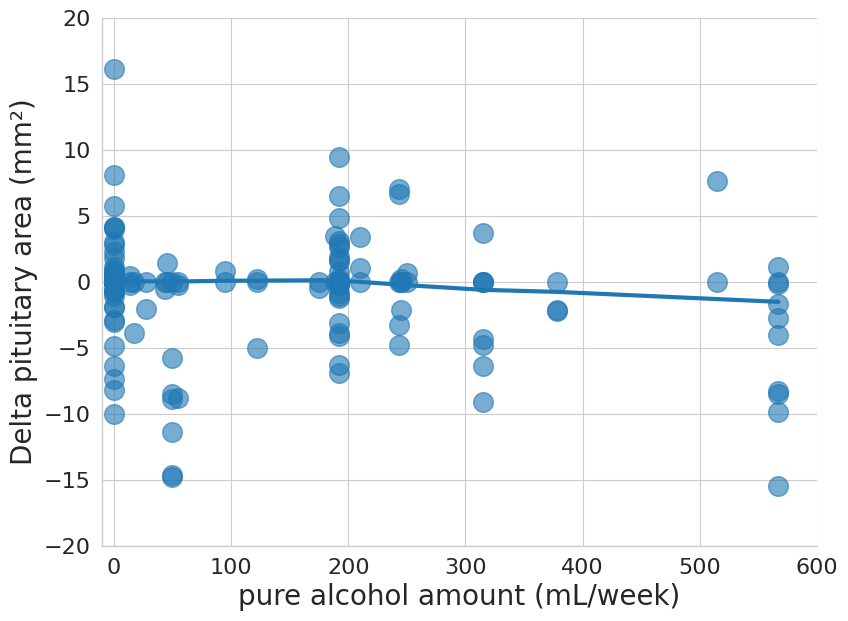

In [61]:
#normality_check(combined_last.yrs_from_baseline)

#combined_base.n_MRI.value_counts(normalize=True)

#compare_continuous_by_group(combined_last, "yrs_from_baseline")

g = sns.lmplot(
    x="alcohol_amount", y="delta_area",
    #hue="male",  # alcohol_label
    col=None, # "alcohol_label"
    data=combined, lowess=True,
    scatter_kws={'alpha':0.6, 's':200},  # smaller dots
    line_kws={'linewidth':3},
    height=6, aspect=1.333,   # → (8, 6)
    legend=None
)
g.set_axis_labels("Pure alcohol amount (mL/week)", "Delta pituitary area (mm²)", fontsize = 20)
g.set_xticklabels(fontsize=16)
g.set_yticklabels(fontsize=16)
g.set(xlim=(-10, None))

#combined.male.value_counts()

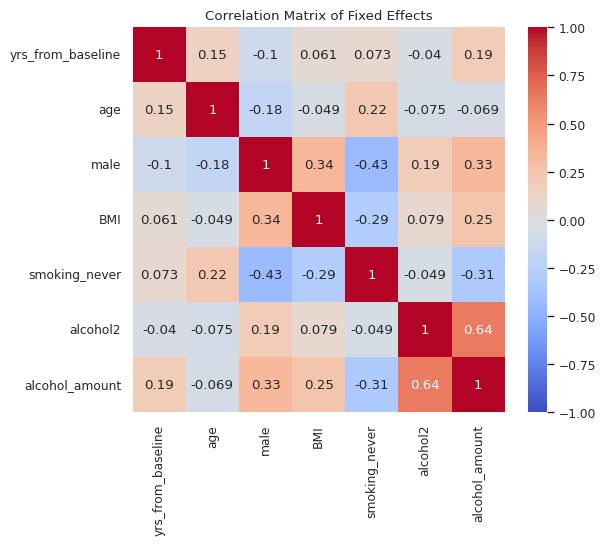

             feature        VIF
0              const  89.972095
1  yrs_from_baseline   1.171414
2                age   1.082641
3               male   1.402251
4                BMI   1.192543
5      smoking_never   1.412173
6           alcohol2   1.889155
7     alcohol_amount   2.277988


In [ ]:
# Suppose your dataset is `combined`
# Select only the fixed-effect variables you want to test
features = ["yrs_from_baseline", "age", "male", "BMI", "smoking_never", "alcohol2", "alcohol_amount"]
X = combined[features]

### 1. Correlation heatmap ###
corr = X.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Fixed Effects")
plt.show()

### 2. VIF calculation ###
# Add constant column for intercept
X_with_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                   for i in range(X_with_const.shape[1])]

print(vif_data)

In [ ]:
model_quad = smf.ols("delta_area ~ alcohol_amount + I(alcohol_amount**2)", data=combined).fit()
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:             delta_area   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     3.400
Date:                Sun, 02 Nov 2025   Prob (F-statistic):             0.0360
Time:                        17:08:34   Log-Likelihood:                -430.06
No. Observations:                 151   AIC:                             866.1
Df Residuals:                     148   BIC:                             875.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

# linear mixed effects model

In [22]:
## linear mixed effects model ##

for i in ["age", "male", "smoking_never", "alcohol2", "alcohol_amount", "yrs_from_baseline", "age50"]:
  model_intercept = smf.mixedlm(
    f"delta_area ~ {i}",  # use f-string to insert variable name
    data=combined,
    groups=combined['"010"']
)
  result_intercept = model_intercept.fit(reml=False)
  print(result_intercept.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: delta_area
No. Observations: 151     Method:             ML        
No. Groups:       52      Scale:              12.3031   
Min. group size:  2       Log-Likelihood:     -422.1301 
Max. group size:  10      Converged:          Yes       
Mean group size:  2.9                                   
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      1.207    2.601  0.464 0.643 -3.891  6.306
age           -0.027    0.043 -0.641 0.522 -0.111  0.056
Group Var      4.622    0.508                           

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: delta_area
No. Observations: 151     Method:             ML        
No. Groups:       52      Scale:              12.3243   
Min. group size:  2       Log-Likelihood:     -418

Best model predictors: ('male', 'alcohol2', 'yrs_from_baseline'), AIC: 835.2761999300856

Top 5 models by AIC:
('male', 'alcohol2', 'yrs_from_baseline') : AIC = 835.2761999300856
('age', 'male', 'alcohol2', 'yrs_from_baseline') : AIC = 836.7658046346455
('male', 'smoking_never', 'alcohol2', 'yrs_from_baseline') : AIC = 837.133497013423
('male', 'alcohol2', 'alcohol_amount', 'yrs_from_baseline') : AIC = 837.1954553428368
('male', 'alcohol_amount', 'yrs_from_baseline') : AIC = 837.6396290754642


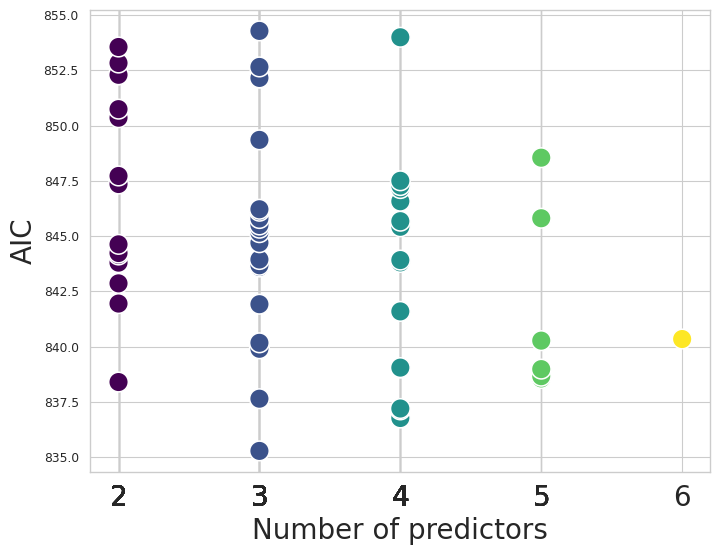

In [ ]:
### linear mixed-effects model, try every combination ###

predictors = ["age", "male", "smoking_never", "alcohol2", "alcohol_amount", "yrs_from_baseline"]
results = []

# try all combinations of length >= 2
for L in range(2, len(predictors)+1):
    for subset in itertools.combinations(predictors, L):
        formula = "delta_area ~ " + " + ".join(subset)
        try:
            model = smf.mixedlm(formula, data=combined, groups=combined['"010"'])
            result = model.fit(reml=False)
            results.append((subset, result.aic))
        except Exception as e:
            print(f"Failed for {subset}: {e}")

# sort by AIC
results.sort(key=lambda x: x[1])

# best model
best_subset, best_aic = results[0]
print(f"Best model predictors: {best_subset}, AIC: {best_aic}")

# optionally, show top 5
print("\nTop 5 models by AIC:")
for subset, aic in results[:5]:
    print(f"{subset} : AIC = {aic}")

## Visualization ##

df_results = pd.DataFrame([
    {"predictors": subset, "n_predictors": len(subset), "AIC": aic}
    for subset, aic in results
])

# Sort for plotting
df_results = df_results.sort_values("AIC")

# Plot AIC vs number of predictors
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_results,
    x="n_predictors", y="AIC",
    hue="n_predictors", palette="viridis", s=200,
    legend=None
)
"""plt.title("Model comparison by AIC")"""
plt.xlabel("Number of predictors", size=20)
plt.xticks(df_results["n_predictors"], size=20)
plt.ylabel("AIC", size=20)
"""plt.legend(title="n_predictors")"""
plt.show()

# linear mixed effects model (multivariable)

In [ ]:
# random intercept by patient ("010")

model_intercept = smf.mixedlm(
    "delta_area ~ male + alcohol2 + yrs_from_baseline",
    data=combined,
    groups=combined['"010"']
)
result_intercept = model_intercept.fit(reml=False)
print(result_intercept.summary())

"""model_slope = smf.mixedlm(
    "delta_area ~ yrs_from_baseline + male + age",
    data=combined,
    groups=combined['"010"'],
    re_formula="~yrs_from_baseline"   # random slope for time
)
result_slope = model_slope.fit(reml=False)
print(result_slope.summary())

print("Intercept+slope AIC:", result_slope.aic)"""

"""# 5. LMM with interaction for full dataset
model_interact = smf.mixedlm(
    "delta_area ~ yrs_from_baseline * male + alcohol2",
    data=combined,
    groups=combined['"010"']
)
result_interact = model_interact.fit(reml=False)
print(result_interact.summary())

# 6. Figure-specific LMMs
results_figs = {}
for alc_value, label in zip([0,1], ["No regular alcohol drinking", "Regular alcohol drinking"]):
    subset = combined[combined["alcohol2"]==alc_value]
    model = smf.mixedlm(
        "delta_area ~ yrs_from_baseline + male",
        data=subset,
        groups=subset['"010"']
    ).fit(reml=False)
    results_figs[label] = model
    print(f"\n{label}:\n", model.summary())"""


           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  delta_area
No. Observations:   151      Method:              ML        
No. Groups:         52       Scale:               11.7036   
Min. group size:    2        Log-Likelihood:      -411.6381 
Max. group size:    10       Converged:           Yes       
Mean group size:    2.9                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         -1.284    1.085 -1.183 0.237 -3.411  0.843
male               3.281    1.055  3.110 0.002  1.213  5.348
alcohol2          -1.836    0.790 -2.324 0.020 -3.385 -0.288
yrs_from_baseline -0.440    0.134 -3.292 0.001 -0.702 -0.178
Group Var          2.386    0.366                           

Intercept-only AIC: 835.2761999300856


'# 5. LMM with interaction for full dataset\nmodel_interact = smf.mixedlm(\n    "delta_area ~ yrs_from_baseline * male + alcohol2",\n    data=combined,\n    groups=combined[\'"010"\']\n)\nresult_interact = model_interact.fit(reml=False)\nprint(result_interact.summary())\n\n# 6. Figure-specific LMMs\nresults_figs = {}\nfor alc_value, label in zip([0,1], ["No regular alcohol drinking", "Regular alcohol drinking"]):\n    subset = combined[combined["alcohol2"]==alc_value]\n    model = smf.mixedlm(\n        "delta_area ~ yrs_from_baseline + male",\n        data=subset,\n        groups=subset[\'"010"\']\n    ).fit(reml=False)\n    results_figs[label] = model\n    print(f"\n{label}:\n", model.summary())'

In [ ]:
results_sex = run_models(combined, "alcohol2", [0,1],
                         ["no alcohol", "alcohol"],
                         inter_var="male")


no alcohol:
               Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    delta_area
No. Observations:    48         Method:                ML        
No. Groups:          16         Scale:                 8.2591    
Min. group size:     2          Log-Likelihood:        -124.7017 
Max. group size:     6          Converged:             Yes       
Mean group size:     3.0                                         
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.029    1.669  0.018 0.986 -3.242  3.301
yrs_from_baseline      -0.828    0.358 -2.312 0.021 -1.530 -0.126
male                   -0.225    1.867 -0.121 0.904 -3.884  3.434
yrs_from_baseline:male  1.593    0.430  3.703 0.000  0.750  2.436
Group Var               3.186    0.832                           


alcohol:

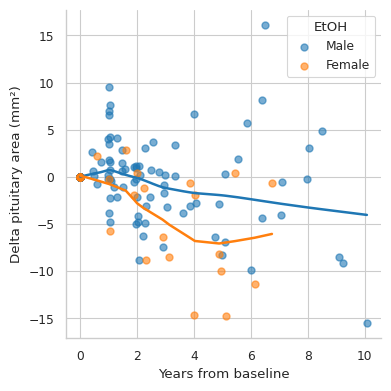

'# 4. Random effects\nrandom_effects = result_intercept.random_effects\nre_df = pd.DataFrame({gid: re["Group"] for gid, re in random_effects.items()}, index=["Random Intercept"]).T\n\nplt.figure(figsize=(8,4))\nsns.stripplot(x=re_df["Random Intercept"], color="blue", size=6, linewidth=0.5)\nplt.title("Random intercepts per patient")\nplt.xlabel("Random effect (intercept shift)")\nplt.show()'

In [ ]:
### visualization ###

"""# 1. Add predictions to dataframe
combined["fitted"] = result_intercept.fittedvalues
combined["residuals"] = combined["delta_area"] - combined["fitted"]

# 2. Observed vs fitted
plt.scatter(combined["fitted"], combined["delta_area"], alpha=0.7)
plt.xlabel("Fitted values")
plt.ylabel("Observed delta_area")
plt.title("Observed vs Fitted values")
plt.axline((0,0), slope=1, color="red", linestyle="--")
plt.show()"""

# 3. Effect of yrs_from_baseline

# Map numeric columns to descriptive labels
combined["sex_label"] = combined["male"].map({0: "Female", 1: "Male"})
combined["alcohol_label"] = combined["alcohol2"].map({0: "No regular alcohol drinking",
                                                      1: "Regular alcohol drinking"})

# Create lmplot
g = sns.lmplot(
    x="yrs_from_baseline", y="delta_area",
    hue="sex_label",  # alcohol_label
    col=None, # "alcohol_label"
    data=combined, lowess=True,
    scatter_kws={'alpha':0.6, 's':25},  # smaller dots
    height=4, aspect=1,  # compact size
    legend=None
)

# Titles and labels
g.set_axis_labels("Years from baseline", "Delta pituitary area (mm²)")
g.set_titles("{col_name}")  # clean facet titles
"""plt.suptitle("Effect of years from baseline on pituitary delta_area by sex and alcohol intake", y=1.05, fontsize=12)"""

# Adjust legend
plt.legend(title="EtOH", loc='upper right')

# Adjust spacing
plt.tight_layout()
plt.show()

"""# 4. Random effects
random_effects = result_intercept.random_effects
re_df = pd.DataFrame({gid: re["Group"] for gid, re in random_effects.items()}, index=["Random Intercept"]).T

plt.figure(figsize=(8,4))
sns.stripplot(x=re_df["Random Intercept"], color="blue", size=6, linewidth=0.5)
plt.title("Random intercepts per patient")
plt.xlabel("Random effect (intercept shift)")
plt.show()"""

In [ ]:
model_intercept = smf.mixedlm(
    "delta_area ~ male * yrs_from_baseline + alcohol2",
    data=combined,
    groups=combined['"010"']
)
result_intercept = model_intercept.fit(reml=False)
print(result_intercept.summary())

In [ ]:
# 3. Annotate lmplot with significance
combined["sex_label"] = combined["male"].map({0: "Female", 1: "Male"})
combined["alcohol_label"] = combined["alcohol2"].map({0: "No regular alcohol drinking",
                                                      1: "Regular alcohol drinking"})

palette = {"Female": "blue", "Male": "orange"}

g = sns.lmplot(
    x="yrs_from_baseline", y="delta_area",
    hue="sex_label", col="alcohol_label",
    data=combined, lowess=False,
    scatter_kws={'alpha':0.6, 's':25},
    palette=palette,
    height=4, aspect=1,
)

g.set_axis_labels("Years from baseline", "Delta pituitary area (mm²)")
g.set_titles("{col_name}")
plt.suptitle("Effect of years from baseline on pituitary delta_area by sex and alcohol intake", y=1.05, fontsize=12)

# Example annotation
for ax, alc_label in zip(g.axes[0], ["No regular alcohol drinking", "Regular alcohol drinking"]):
    model = results_figs[alc_label]
    slope_p = model.pvalues["yrs_from_baseline"]
    intercept_p = model.pvalues["male"]
    ax.text(0.05, 0.95, f"Slope p={slope_p:.3f}\nIntercept p={intercept_p:.3f}",
            transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

In [ ]:
## metrics for figures ##

# fitted values from the result object
fitted = result_intercept.fittedvalues

# variance of fitted values (fixed effects only)
var_fixed = np.var(fitted)

# variance components from result
var_random = float(result_intercept.cov_re.iloc[0, 0])  # Group Var
var_resid = result_intercept.scale                      # Residual (Scale)

# R² metrics
R2_m = var_fixed / (var_fixed + var_random + var_resid)
R2_c = (var_fixed + var_random) / (var_fixed + var_random + var_resid)

print("Marginal R²:", R2_m)
print("Conditional R²:", R2_c)

In [ ]:
# --- scatter only (hue = male) ---
plt.figure(figsize=(6,5))
scatter = plt.scatter(
    combined["yrs_from_baseline"],
    combined["delta_area"],
    c=combined["male"],  # change to combined["smoking_never"] if you want that hue
    cmap="coolwarm",
    s=80,
    alpha=0.8
)
plt.ylabel("Δ Pituitary Area (mm²) from Baseline")
plt.xlabel("Years from Baseline")
plt.title("Change in Pituitary Area over Time")
plt.legend(*scatter.legend_elements(), title="Male")  # change title if hue = smoking
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# --- scatter + trajectory lines (per patient) ---
plt.figure(figsize=(6,5))
for pid, df in combined.groupby('"010"'):
    plt.plot(
        df["yrs_from_baseline"],
        df["delta_area"],
        marker="o",
        label=f"ID {pid}"
    )

plt.ylabel("Δ Pituitary Area (mm²) from Baseline")
plt.xlabel("Years from Baseline")
plt.title("Individual Trajectories of Pituitary Area Change")
#plt.legend(title="Patient ID")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()